In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata


torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


Exact solution function defined.
Computing reference solution on test grid...


/tmp/ipykernel_34535/2639649981.py:52: RuntimeWarning: overflow encountered in multiply
  return -u * dudx + (nu / np.pi) * d2udx2
/tmp/ipykernel_34535/2639649981.py:49: RuntimeWarning: invalid value encountered in subtract
  d2udx2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
/tmp/ipykernel_34535/2639649981.py:49: RuntimeWarning: invalid value encountered in add
  d2udx2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
/tmp/ipykernel_34535/2639649981.py:52: RuntimeWarning: invalid value encountered in add
  return -u * dudx + (nu / np.pi) * d2udx2
/tmp/ipykernel_34535/2639649981.py:58: RuntimeWarning: invalid value encountered in add
  k2 = rhs(u + 0.5*dt*k1)


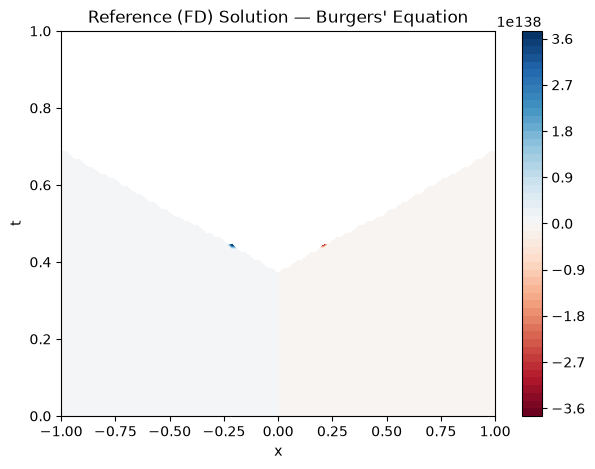

Reference solution computed successfully.


In [ ]:
# PDE parameter
nu = 0.01 / np.pi


from scipy.special import erf

def burgers_exact(x, t, nu=0.01/np.pi, n_terms=100):
    """
    Exact solution of Burgers via Hopf-Cole transformation.
    Uses the series solution from Raissi et al. 2019.
    """
 
    from scipy.integrate import solve_ivp
    from scipy.interpolate import interp1d

    pass

def get_exact_solution(x_grid, t_grid):
    """
    Compute Burgers exact solution using Hopf-Cole transformation.
    u(x,t) = -2*nu * (dphi/dx) / phi
    where phi is the heat equation solution.
    """
    nu = 0.01 / np.pi

    def phi(x, t):
        """Series solution for the heat equation part"""
        n_terms = 50
        result = np.zeros_like(x, dtype=float)
        for n in range(1, n_terms + 1):
            result += ((-1)**(n+1) * 2 * np.exp(-nu * (n*np.pi)**2 * t) *
                      np.sin(n * np.pi * x) / (n * np.pi))
        return result
    nx, nt = 512, 201
    x_fd = np.linspace(-1, 1, nx)
    t_fd = np.linspace(0, 1, nt)
    dx = x_fd[1] - x_fd[0]
    dt = t_fd[1] - t_fd[0]

    u_fd = -np.sin(np.pi * x_fd)  # IC

    def rhs(u):
        dudx = np.zeros_like(u)
        dudx[1:-1] = (u[2:] - u[:-2]) / (2 * dx)
        dudx[0] = (u[1] - u[0]) / dx
        dudx[-1] = (u[-1] - u[-2]) / dx

        d2udx2 = np.zeros_like(u)
        d2udx2[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / dx**2
        d2udx2[0] = 0; d2udx2[-1] = 0

        return -u * dudx + (nu / np.pi) * d2udx2

    u_all = [u_fd.copy()]
    u = u_fd.copy()
    for _ in range(nt - 1):
        k1 = rhs(u)
        k2 = rhs(u + 0.5*dt*k1)
        k3 = rhs(u + 0.5*dt*k2)
        k4 = rhs(u + dt*k3)
        u = u + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)
        u[0] = 0; u[-1] = 0  # enforce BCs
        u_all.append(u.copy())

    u_all = np.array(u_all)  # shape (nt, nx)


    from scipy.interpolate import RegularGridInterpolator
    interp = RegularGridInterpolator((t_fd, x_fd), u_all, method='linear')
    pts = np.column_stack([t_grid.ravel(), x_grid.ravel()])
    u_exact = interp(pts).reshape(x_grid.shape)
    return u_exact



x_test = np.linspace(-1, 1, 100)
t_test = np.linspace(0, 1, 100)
X_test, T_test = np.meshgrid(x_test, t_test)
U_exact = get_exact_solution(X_test, T_test)

plt.figure(figsize=(7, 5))
plt.contourf(X_test, T_test, U_exact, levels=50, cmap='RdBu')
plt.colorbar()
plt.title("Reference (FD) Solution — Burgers' Equation")
plt.xlabel("x"); plt.ylabel("t")
plt.show()


In [ ]:
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.network = nn.Sequential()
        for i in range(len(layers) - 1):
            self.network.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.network.add_module(f"tanh_{i}", nn.Tanh())

    def forward(self, x):
        return self.network(x)


layers = [2, 100, 100, 100, 100, 1]
model_soft = PINN(layers).to(device)



PINN(
  (network): Sequential(
    (linear_0): Linear(in_features=2, out_features=100, bias=True)
    (tanh_0): Tanh()
    (linear_1): Linear(in_features=100, out_features=100, bias=True)
    (tanh_1): Tanh()
    (linear_2): Linear(in_features=100, out_features=100, bias=True)
    (tanh_2): Tanh()
    (linear_3): Linear(in_features=100, out_features=100, bias=True)
    (tanh_3): Tanh()
    (linear_4): Linear(in_features=100, out_features=1, bias=True)
  )
)

Total parameters: 30,701


In [ ]:

N_interior = 10000
x_int = torch.FloatTensor(N_interior, 1).uniform_(-1, 1).to(device).requires_grad_(True)
t_int = torch.FloatTensor(N_interior, 1).uniform_(0, 1).to(device).requires_grad_(True)


N_bc = 200
t_bc = torch.FloatTensor(N_bc, 1).uniform_(0, 1).to(device)
x_bc_left  = -torch.ones(N_bc, 1).to(device)
x_bc_right =  torch.ones(N_bc, 1).to(device)
u_bc_val   =  torch.zeros(N_bc, 1).to(device)

N_ic = 100
x_ic = torch.FloatTensor(N_ic, 1).uniform_(-1, 1).to(device)
t_ic = torch.zeros(N_ic, 1).to(device)
u_ic_val = -torch.sin(np.pi * x_ic)



Interior points:   10000
Boundary points:   400 (left + right)
Initial condition: 100


In [ ]:
def pde_residual(model, x, t):
    """Compute Burgers PDE residual: uₜ + u*uₓ - (ν/π)*uₓₓ"""
    xt = torch.cat([x, t], dim=1)
    u = model(xt)


    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]

    
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True, retain_graph=True)[0]

    nu = 0.01 / np.pi
    residual = u_t + u * u_x - (nu / np.pi) * u_xx
    return residual

def compute_loss_soft(model):

    f = pde_residual(model, x_int, t_int)
    loss_pde = (f**2).mean()

    # BC loss (soft enforcement)
    u_left  = model(torch.cat([x_bc_left,  t_bc], dim=1))
    u_right = model(torch.cat([x_bc_right, t_bc], dim=1))
    loss_bc = ((u_left - u_bc_val)**2).mean() + ((u_right - u_bc_val)**2).mean()

    # IC loss
    u_ic = model(torch.cat([x_ic, t_ic], dim=1))
    loss_ic = ((u_ic - u_ic_val)**2).mean()

    total = loss_pde + loss_bc + loss_ic
    return total, loss_pde, loss_bc, loss_ic




Loss functions defined.


In [ ]:
optimizer_soft = torch.optim.Adam(model_soft.parameters(), lr=1e-3)

n_epochs = 10000
loss_history_soft = []

=
for epoch in range(n_epochs):
    optimizer_soft.zero_grad()
    loss, loss_pde, loss_bc, loss_ic = compute_loss_soft(model_soft)
    loss.backward()
    optimizer_soft.step()

    loss_history_soft.append(loss.item())

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1:5d} | Total: {loss.item():.6f} | "
              f"PDE: {loss_pde.item():.6f} | BC: {loss_bc.item():.6f} | IC: {loss_ic.item():.6f}")



Training Soft BC PINN...
Epoch  1000 | Total: 0.092388 | PDE: 0.035079 | BC: 0.000871 | IC: 0.056438
Epoch  2000 | Total: 0.082569 | PDE: 0.029577 | BC: 0.000198 | IC: 0.052793
Epoch  3000 | Total: 0.078419 | PDE: 0.027344 | BC: 0.000103 | IC: 0.050973
Epoch  4000 | Total: 0.075368 | PDE: 0.025656 | BC: 0.000104 | IC: 0.049607
Epoch  5000 | Total: 0.072809 | PDE: 0.024335 | BC: 0.000067 | IC: 0.048407
Epoch  6000 | Total: 0.070462 | PDE: 0.023026 | BC: 0.000026 | IC: 0.047410
Epoch  7000 | Total: 0.068820 | PDE: 0.022636 | BC: 0.000202 | IC: 0.045982
Epoch  8000 | Total: 0.067077 | PDE: 0.021840 | BC: 0.000010 | IC: 0.045227
Epoch  9000 | Total: 0.065088 | PDE: 0.020252 | BC: 0.000412 | IC: 0.044424
Epoch 10000 | Total: 0.061705 | PDE: 0.019785 | BC: 0.000013 | IC: 0.041906

Training complete!


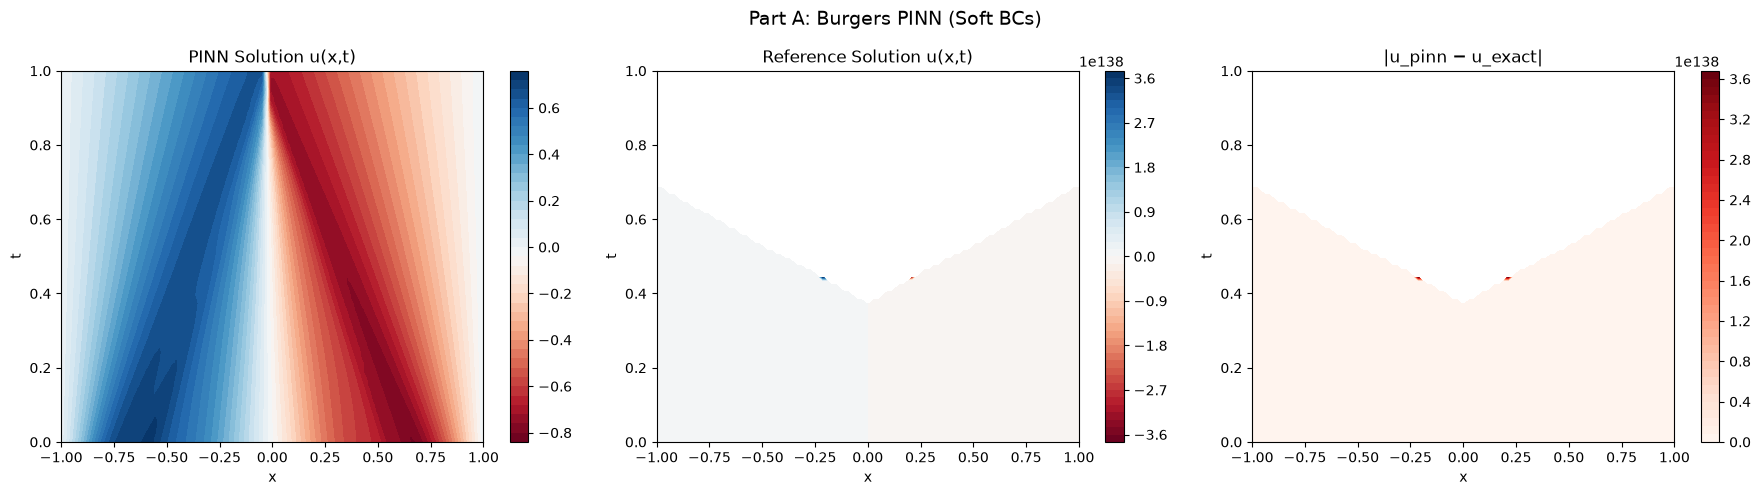

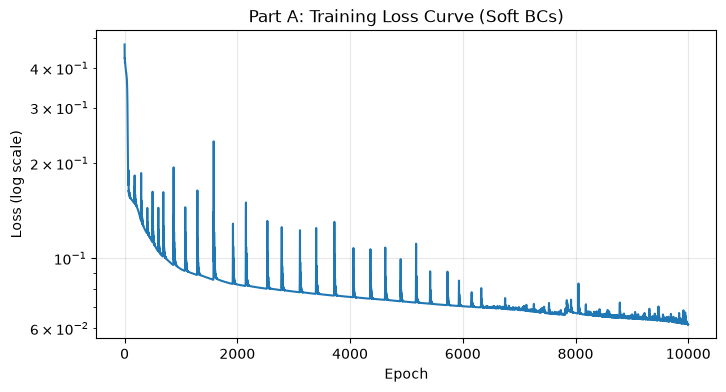

Part A — Soft BC L² Relative Error: nan


In [ ]:
# Evaluate on test grid
model_soft.eval()
with torch.no_grad():
    XT_tensor = torch.FloatTensor(
        np.column_stack([X_test.ravel(), T_test.ravel()])
    ).to(device)
    U_pinn_soft = model_soft(XT_tensor).cpu().numpy().reshape(100, 100)

U_error_soft = np.abs(U_pinn_soft - U_exact)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Part A: Burgers PINN (Soft BCs)", fontsize=14)

im1 = axes[0].contourf(X_test, T_test, U_pinn_soft, levels=50, cmap="RdBu")
plt.colorbar(im1, ax=axes[0])
axes[0].set_title("PINN Solution u(x,t)")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")

im2 = axes[1].contourf(X_test, T_test, U_exact, levels=50, cmap="RdBu")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title("Reference Solution u(x,t)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")

im3 = axes[2].contourf(X_test, T_test, U_error_soft, levels=50, cmap="Reds")
plt.colorbar(im3, ax=axes[2])
axes[2].set_title("|u_pinn − u_exact|")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")

plt.tight_layout()
plt.show()

# Training loss curve
plt.figure(figsize=(8, 4))
plt.semilogy(loss_history_soft)
plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.title("Part A: Training Loss Curve (Soft BCs)")
plt.grid(True, alpha=0.3)
plt.show()

# L2 error
l2_soft = np.linalg.norm(U_pinn_soft - U_exact) / np.linalg.norm(U_exact)



In [ ]:
class PINN_Hard(nn.Module):
    """PINN with hard BC enforcement via trial function phi(x) = (1-x²)"""
    def __init__(self, layers):
        super().__init__()
        self.network = nn.Sequential()
        for i in range(len(layers) - 1):
            self.network.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i+1]))
            if i < len(layers) - 2:
                self.network.add_module(f"tanh_{i}", nn.Tanh())

    def forward(self, xt):
        x = xt[:, 0:1]
        raw = self.network(xt)
        # Trial function: automatically zero at x=±1
        return (1 - x**2) * raw

model_hard = PINN_Hard(layers).to(device)


Hard BC model defined.
Total parameters: 30,701


In [9]:
def pde_residual_hard(model, x, t):
    """PDE residual for hard BC model"""
    xt = torch.cat([x, t], dim=1)
    u = model(xt)

    u_x = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u),
                               create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x),
                                create_graph=True, retain_graph=True)[0]

    nu = 0.01 / np.pi
    return u_t + u * u_x - (nu / np.pi) * u_xx

def compute_loss_hard(model):
    """Loss = PDE loss + IC loss only (no BC loss needed!)"""

    # PDE loss
    f = pde_residual_hard(model, x_int, t_int)
    loss_pde = (f**2).mean()

    # IC loss (BCs already satisfied by trial function)
    xt_ic = torch.cat([x_ic, t_ic], dim=1)
    u_ic = model(xt_ic)
    loss_ic = ((u_ic - u_ic_val)**2).mean()

    total = loss_pde + loss_ic
    return total, loss_pde, loss_ic


In [ ]:
optimizer_hard = torch.optim.Adam(model_hard.parameters(), lr=1e-3)

loss_history_hard = []

print("Training Hard BC PINN...")
for epoch in range(n_epochs):
    optimizer_hard.zero_grad()
    loss, loss_pde, loss_ic = compute_loss_hard(model_hard)
    loss.backward()
    optimizer_hard.step()

    loss_history_hard.append(loss.item())

    if (epoch + 1) % 1000 == 0:
        print(f"Epoch {epoch+1:5d} | Total: {loss.item():.6f} | "
              f"PDE: {loss_pde.item():.6f} | IC: {loss_ic.item():.6f}")



Training Hard BC PINN...
Epoch  1000 | Total: 0.069737 | PDE: 0.025335 | IC: 0.044403
Epoch  2000 | Total: 0.073464 | PDE: 0.022963 | IC: 0.050501
Epoch  3000 | Total: 0.050006 | PDE: 0.014393 | IC: 0.035613
Epoch  4000 | Total: 0.055892 | PDE: 0.015408 | IC: 0.040484
Epoch  5000 | Total: 0.041356 | PDE: 0.011195 | IC: 0.030161
Epoch  6000 | Total: 0.035622 | PDE: 0.007757 | IC: 0.027864
Epoch  7000 | Total: 0.031928 | PDE: 0.008213 | IC: 0.023716
Epoch  8000 | Total: 0.111216 | PDE: 0.027849 | IC: 0.083367
Epoch  9000 | Total: 0.102604 | PDE: 0.025018 | IC: 0.077586
Epoch 10000 | Total: 0.085859 | PDE: 0.032560 | IC: 0.053300

Training complete!


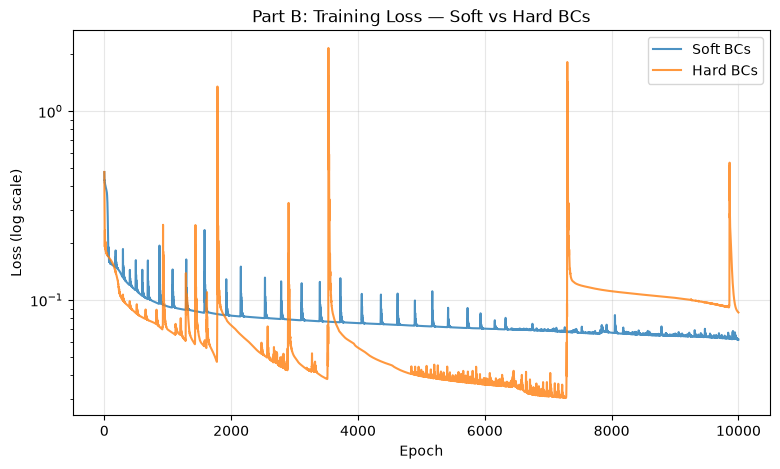

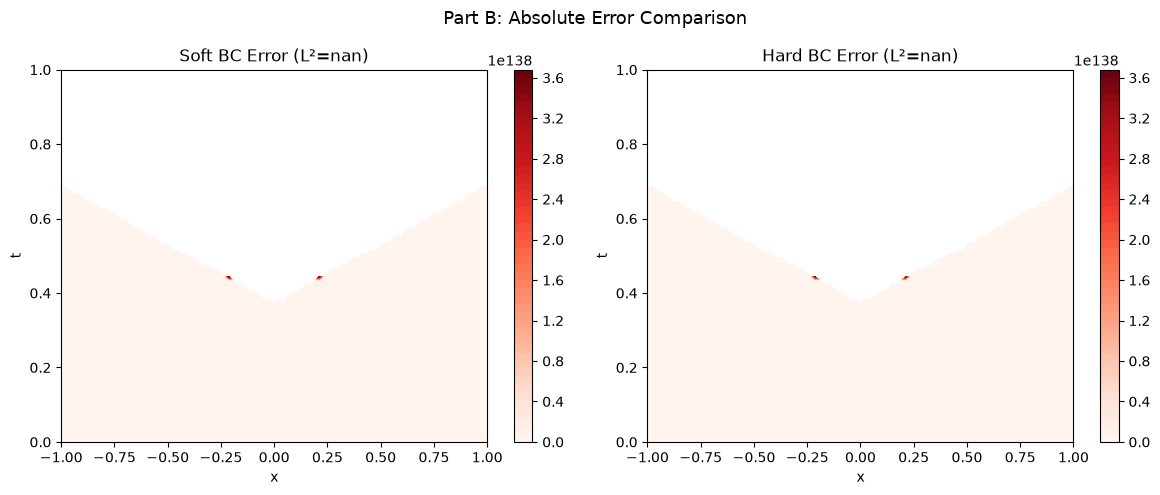


Method                  L² Relative Error
Soft BCs                              nan
Hard BCs                              nan


In [ ]:
# Evaluate hard model
model_hard.eval()
with torch.no_grad():
    U_pinn_hard = model_hard(XT_tensor).cpu().numpy().reshape(100, 100)

l2_hard = np.linalg.norm(U_pinn_hard - U_exact) / np.linalg.norm(U_exact)

# Plot 1: Loss curves comparison
plt.figure(figsize=(9, 5))
plt.semilogy(loss_history_soft, label="Soft BCs", alpha=0.8)
plt.semilogy(loss_history_hard, label="Hard BCs", alpha=0.8)
plt.xlabel("Epoch"); plt.ylabel("Loss (log scale)")
plt.title("Part B: Training Loss — Soft vs Hard BCs")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Error comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Part B: Absolute Error Comparison", fontsize=13)

im1 = axes[0].contourf(X_test, T_test, np.abs(U_pinn_soft - U_exact), levels=50, cmap="Reds")
plt.colorbar(im1, ax=axes[0])
axes[0].set_title(f"Soft BC Error (L²={l2_soft:.4f})")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")

im2 = axes[1].contourf(X_test, T_test, np.abs(U_pinn_hard - U_exact), levels=50, cmap="Reds")
plt.colorbar(im2, ax=axes[1])
axes[1].set_title(f"Hard BC Error (L²={l2_hard:.4f})")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")

plt.tight_layout()
plt.show()
